In [4]:
from pydriller import Repository
from datetime import datetime, timedelta
from collections import defaultdict
from git.exc import GitCommandError
from scipy.stats import mannwhitneyu
import pandas as pd
from cliffs_delta import cliffs_delta
from statistics import median
import numpy as np
import os

In [5]:
def get_project_name(path):
    # Extract folder name (e.g., "ompi" from ".../Scientific_Projects/ompi/ompi_processed.csv")
    return os.path.basename(os.path.dirname(path))

In [6]:
def get_repo_name(github_url):
    """
    Extracts the repository name from a GitHub URL.

    Parameters:
        github_url (str): The full GitHub URL (e.g., 'https://github.com/open-mpi/ompi').

    Returns:
        str: The repository name (e.g., 'ompi').
    """
    return github_url.rstrip('/').split('/')[-1]

# Using Commit frequency

In [1557]:
k=32

In [9]:
# Step 2: Apply function to extract repo names
repo_names = selected_df[selected_df['commits_last_1_year']/12 >= k]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()
print(processed_paths_list)
df_list = [pd.read_csv(f) for f in processed_paths_list]
sustainable_df = pd.concat(df_list, ignore_index=True)
sustainable_df['Comment_Density'] = sustainable_df['LOCCOM'] / sustainable_df['line_total']
len(sustainable_df)

['/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/ompi/ompi_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/mfem/mfem_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/dyninst/dyninst_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/hypre/hypre_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/hdf5/hdf5_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/amrex/amrex_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/mpich/mpich_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/sundials/sundials_processed.csv', '/Users/srahma14/Li

6151

In [1559]:
# Step 2: Apply function to extract repo names
repo_names = selected_df[selected_df['commits_last_1_year']/12 < k]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "/Users/mushfiq344/ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()
print(processed_paths_list)
df_list = [pd.read_csv(f) for f in processed_paths_list]
unsustainable_df = pd.concat(df_list, ignore_index=True)
unsustainable_df['Comment_Density'] = unsustainable_df['LOCCOM'] / unsustainable_df['line_total']
unsustainable_df

['/Users/mushfiq344/ORNL/Scientific_Projects/zfp/zfp_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/dyninst/dyninst_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/hypre/hypre_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/amrex/amrex_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/sundials/sundials_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/superlu/superlu_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/superlu_dist/superlu_dist_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/STRUMPACK/STRUMPACK_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/diy/diy_processed.csv', '/Users/mushfiq344/ORNL/Scientific_Projects/superlu_mt/superlu_mt_processed.csv']


,filename,line_total,line_covered,line_percent,branch_total,branch_covered,branch_percent,function_total,function_covered,function_percent,...,RFC,SC,LOCCOM,NSM,NMC,NMCI,NMCE,WMC,AMC,Comment_Density
0,include/zfp/array.hpp,6,6,1.000,0,0,NaN,2,2,1.000,...,49,20,0,5467,0,0,5467,10.8,1.2,0.000000
1,include/zfp/internal/array/exception.hpp,2,0,0.000,0,0,NaN,2,0,0.000,...,2,0,0,5360,0,0,5360,2.0,1.0,0.000000
2,include/zfp/internal/array/memory.hpp,35,28,0.800,8,5,0.625,21,21,1.000,...,25,4,0,3717,0,0,3717,27.5,2.5,0.000000
3,include/zfp/internal/array/store1.hpp,44,33,0.750,20,6,0.300,26,22,0.846,...,16,0,0,2,0,0,2,19.2,1.2,0.000000
4,include/zfp/internal/array/store2.hpp,49,38,0.776,24,8,0.333,28,24,0.857,...,17,0,0,2,0,0,2,20.4,1.2,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691,TESTING/sp_cconvert.c,16,16,1.000,8,7,0.875,1,1,1.000,...,1,0,16,7,0,0,7,3.0,3.0,1.000000
2692,TESTING/sp_dconvert.c,16,16,1.000,8,8,1.000,1,1,1.000,...,1,0,16,7,0,0,7,3.0,3.0,1.000000
2693,TESTING/sp_ienv.c,14,11,0.786,9,8,0.889,1,1,1.000,...,2,1,64,8,0,0,8,39.0,39.0,4.571429
2694,TESTING/sp_sconvert.c,16,16,1.000,8,8,1.000,1,1,1.000,...,1,0,16,7,0,0,7,3.0,3.0,1.000000


In [1560]:
metric_columns = sustainable_df.select_dtypes(include='number').columns.tolist()

# Cliff's delta

In [1561]:
# Run statistical test and collect results
results = []
for col in metric_columns:
    s_vals = sustainable_df[col].dropna()
    u_vals = unsustainable_df[col].dropna()
    if not s_vals.empty and not u_vals.empty:
        stat, p = mannwhitneyu(s_vals, u_vals, alternative='two-sided')
        results.append({
            'Metric': col,
            'Sustainable_Mean': s_vals.mean(),
            'Unsustainable_Mean': u_vals.mean(),
            'U_Statistic': stat,
            'p_Value': p
        })

# Convert results to DataFrame and sort by p-value
results_df = pd.DataFrame(results).sort_values(by="p_Value")

# Print results
print(results_df.to_string(index=False))

          Metric  Sustainable_Mean  Unsustainable_Mean  U_Statistic      p_Value
             NMC        212.655667            0.024481    8634670.0 0.000000e+00
             NSM        867.839554         3359.967359    2503532.5 0.000000e+00
              SC         47.522758           65.057864    4227579.5 5.268316e-94
             CBO          6.009558            6.844955    4451445.0 2.028175e-71
function_covered          5.808375            4.337908    7334590.5 2.082813e-70
function_percent          0.548182            0.342668    6946775.0 1.377339e-66
             RFC         54.447883           57.525223    4633200.5 1.000968e-53
             ACC          5.528220            5.432493    4773527.0 3.093813e-50
  branch_covered         67.164087           22.163576    6974753.0 5.434570e-41
    line_covered         93.303596           39.604599    6968556.0 1.259640e-39
    line_percent          0.437726            0.296830    6948114.0 3.595256e-38
  branch_percent          0.

In [1562]:
significant_df = results_df[results_df["p_Value"] < 0.05]
significant_df

,Metric,Sustainable_Mean,Unsustainable_Mean,U_Statistic,p_Value
18,NMC,212.655667,0.024481,8634670.0,0.000000e+00
17,NSM,867.839554,3359.967359,2503532.5,0.000000e+00
15,SC,47.522758,65.057864,4227579.5,5.268316e-94
10,CBO,6.009558,6.844955,4451445.0,2.028175e-71
7,function_covered,5.808375,4.337908,7334590.5,2.082813e-70
8,function_percent,0.548182,0.342668,6946775.0,1.377339e-66
14,RFC,54.447883,57.525223,4633200.5,1.000968e-53
9,ACC,5.528220,5.432493,4773527.0,3.093813e-50
4,branch_covered,67.164087,22.163576,6974753.0,5.434570e-41
1,line_covered,93.303596,39.604599,6968556.0,1.259640e-39


In [1563]:

# Calculate the mean difference
results_df["Mean_Difference"] = results_df["Sustainable_Mean"] - results_df["Unsustainable_Mean"]

# Filter for positively correlated metrics with statistically significant difference
positively_correlated = results_df[(results_df["Mean_Difference"] > 0) & (results_df["p_Value"] < 0.05)]
positively_correlated["Metric"]

18                 NMC
7     function_covered
8     function_percent
9                  ACC
4       branch_covered
1         line_covered
2         line_percent
5       branch_percent
21                 WMC
23     Comment_Density
0           line_total
16              LOCCOM
Name: Metric, dtype: object

In [1564]:
negatively_correlated = results_df[(results_df["Mean_Difference"] < 0) & (results_df["p_Value"] < 0.05)]
negatively_correlated["Metric"]

17               NSM
15                SC
10               CBO
14               RFC
11             LCOM4
13               NOM
6     function_total
Name: Metric, dtype: object

In [1565]:
results = []

for col in metric_columns:
    x1 = sustainable_df[col].dropna().abs()
    x2 = unsustainable_df[col].dropna().abs()


    if x1.empty or x2.empty:
        continue

    d, res = cliffs_delta(x1, x2)
    results.append({
        "Metric": col,
        "Cliffs_Delta": round(d, 4),
        "Effect_Size": res
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)


# Remove unwanted metrics
results_df = results_df[~results_df["Metric"].isin(["branch_covered", "line_covered","function_covered","NOM","NSM"])]

# Rename percent metrics for better labels
results_df["Metric"] = results_df["Metric"].replace({
    "branch_percent": "BC",
    "line_percent": "LC",
    "function_percent": "FC",
    "branch_total": "NOB",
    "line_total": "LOC",
    "Comment_Density":"CD",
    "function_total":"NOM"
})
results_df["Cliffs_Delta"].to_list()

[-0.047,
 0.1731,
 0.0272,
 0.168,
 0.0299,
 0.2325,
 -0.1941,
 -0.2485,
 -0.0904,
 -0.0025,
 -0.2178,
 -0.2863,
 -0.0295,
 0.4578,
 -0.0044,
 -0.0183,
 -0.1156,
 -0.0116,
 0.0954]

In [1566]:
threshold_cd.loc[len(threshold_cd)] = [k]+results_df["Cliffs_Delta"].to_list()

In [1567]:
threshold_cd

,$C_{th}$,LOC,LC,NOB,BC,NOM,FC,ACC,CBO,LCOM4,NOA,RFC,SC,LOCCOM,NMC,NMCI,NMCE,WMC,AMC,CD
0,2.0,0.0132,-0.1812,0.1555,-0.2465,0.5114,-0.1798,-0.0058,-0.0813,0.4048,0.1864,0.0905,0.0561,-0.4924,0.3070,0.0123,0.4229,0.0150,-0.4732,-0.5308
1,4.0,0.0730,-0.2012,0.1330,-0.2123,0.1834,-0.1349,-0.0280,-0.0856,0.1547,0.0927,-0.0235,-0.0329,-0.1457,0.3131,0.0030,0.2749,0.0110,-0.2337,-0.2099
2,8.0,-0.0790,0.0727,0.1013,0.0306,0.1084,0.1205,-0.1937,-0.1163,0.0624,0.1741,-0.0438,-0.1320,-0.3213,0.3715,0.0115,0.3262,-0.0348,-0.1833,-0.2378
3,16.0,-0.0374,0.1809,0.0409,0.1435,0.1185,0.2140,-0.1809,-0.1662,-0.0279,0.0383,-0.1144,-0.1962,-0.1026,0.4169,-0.0046,0.0691,-0.0620,-0.0752,-0.0084
4,32.0,-0.0470,0.1731,0.0272,0.1680,0.0299,0.2325,-0.1941,-0.2485,-0.0904,-0.0025,-0.2178,-0.2863,-0.0295,0.4578,-0.0044,-0.0183,-0.1156,-0.0116,0.0954


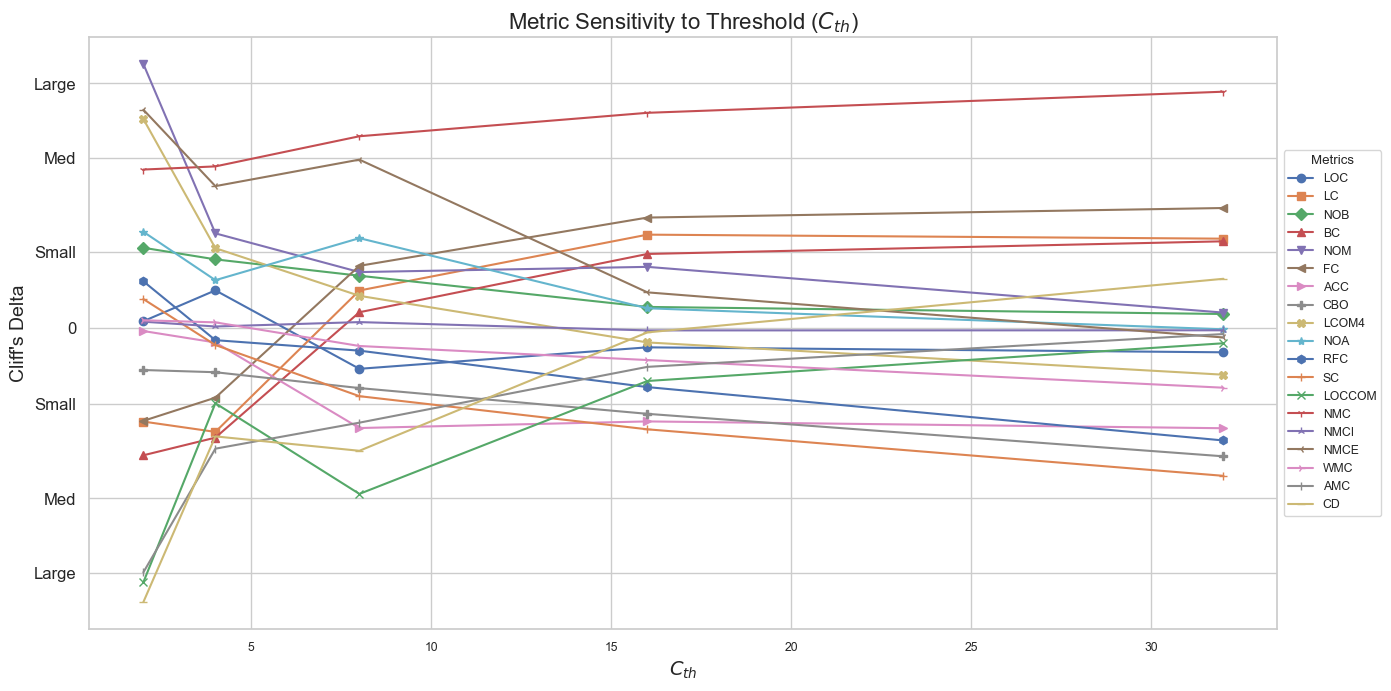

In [1576]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv("threshold_cd.csv")
df = df.rename(columns={"$C_{th}$": "C_th"})
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# List of marker styles (extend as needed)
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X', '*', 'h', '+', 'x', '1', '2', '3', '4', '|', '_']
metric_columns = [col for col in df.columns if col != "C_th"]

# Create plot
plt.figure(figsize=(14, 7))
x = df["C_th"]

# Plot each metric with a different marker
for i, col in enumerate(metric_columns):
    marker = markers[i % len(markers)]  # cycle through markers
    plt.plot(x, df[col], label=col, marker=marker)

# Axis labels and title
plt.xlabel("$C_{th}$", fontsize=14)
plt.ylabel("Cliff's Delta", fontsize=14)
plt.title("Metric Sensitivity to Threshold ($C_{th}$)", fontsize=16)

# Custom y-ticks for Cliff's Delta effect sizes
plt.yticks(
    ticks=[-0.474, -0.33, -0.147, 0, 0.147, 0.33, 0.474],
    labels=["Large", "Med", "Small", "0", "Small", "Med", "Large"],
    fontsize=12
)

plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Metrics")
plt.tight_layout()
plt.savefig("threshold_metrics_plot.pdf")
plt.show()

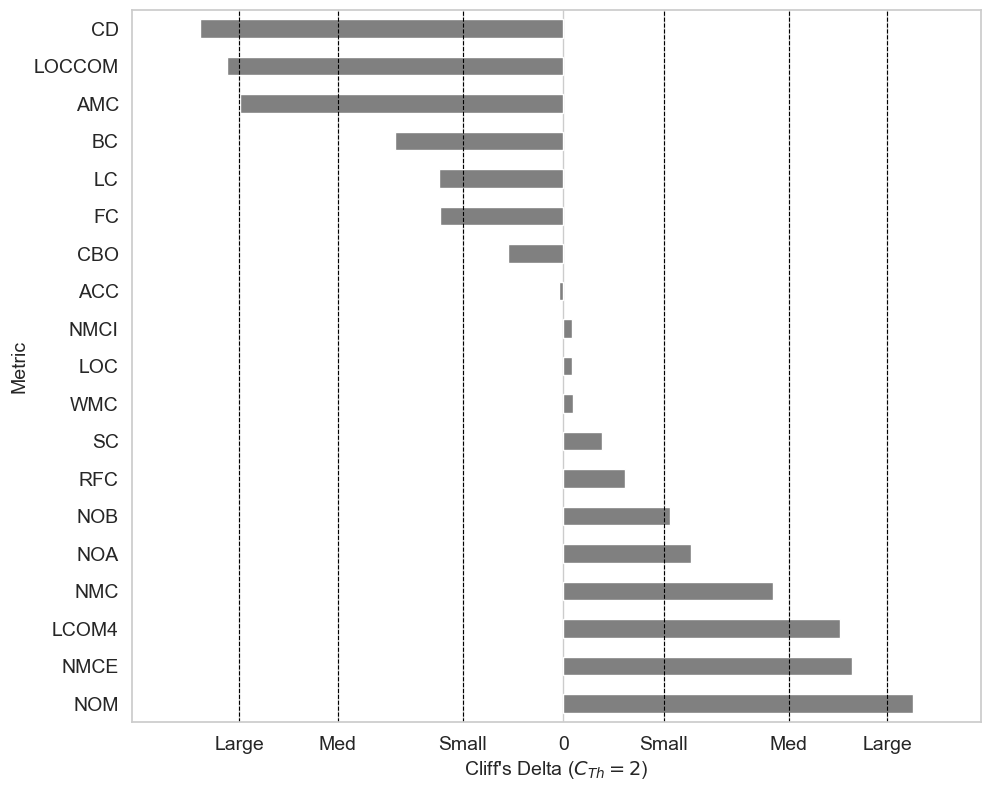

In [1432]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remove unwanted metrics
results_df = results_df[~results_df["Metric"].isin(["branch_covered", "line_covered","function_covered","NOM","NSM"])]

# Rename percent metrics for better labels
results_df["Metric"] = results_df["Metric"].replace({
    "branch_percent": "BC",
    "line_percent": "LC",
    "function_percent": "FC",
    "branch_total": "NOB",
    "line_total": "LOC",
    "Comment_Density":"CD",
    "function_total":"NOM"
})

# Sort metrics by Cliff's Delta
results_df = results_df.sort_values("Cliffs_Delta")

# Set style and figure
sns.set(style="whitegrid", font_scale=0.8)
plt.figure(figsize=(10, 8))

# Horizontal bar plot with reduced width
sns.barplot(
    x="Cliffs_Delta",
    y="Metric",
    data=results_df,
    color="gray",
    width=0.5
)

# Add vertical lines for Cliff’s Delta thresholds (effect sizes)
for threshold in [0.147, 0.33, 0.474]:
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=-threshold, color='black', linestyle='--', linewidth=0.8)

# Adjust x-axis range to fit data with margin
min_val = results_df["Cliffs_Delta"].min()
max_val = results_df["Cliffs_Delta"].max()
plt.xlim(min_val - 0.1, max_val + 0.1)  # 0.1 is margin

# Set custom x-axis ticks and labels
plt.xticks(
    ticks=[-0.474, -0.33, -0.147, 0, 0.147, 0.33, 0.474],
    labels=["Large", "Med", "Small", "0", "Small", "Med", "Large"],
    fontsize=14
)

# Y-axis (metrics)
plt.yticks(fontsize=14)

# Axis labels and title
plt.xlabel(f"Cliff's Delta ($C_{{Th}} = {k}$)", fontsize=14)
plt.ylabel("Metric", fontsize=14)
# plt.title("Cliff's Delta by Metric", fontsize=14)

# Layout
plt.tight_layout()
plt.savefig(f"cliffs_delta_for_cf_{k}.png", dpi=300, bbox_inches='tight')  # or use .pdf
plt.show()


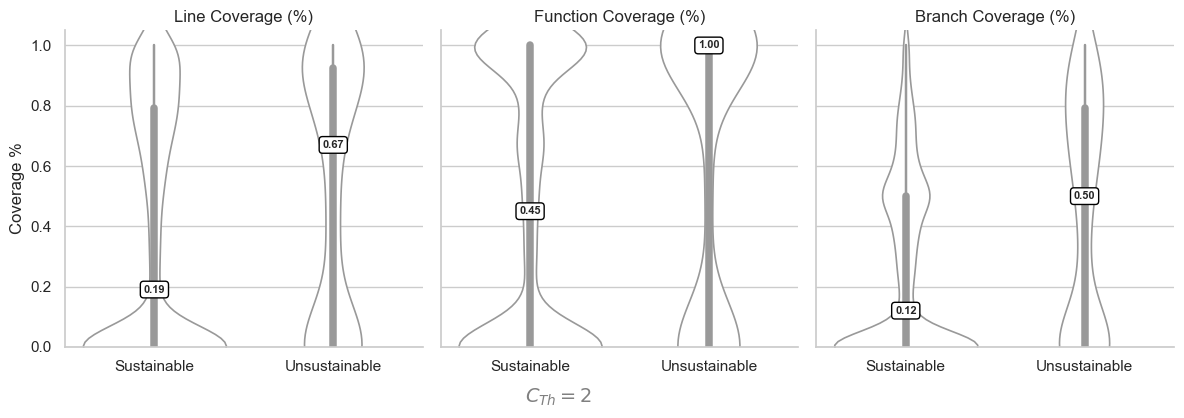

In [1433]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Commit frequency threshold value


# Define the 3 metrics
metrics = [
    ("line_percent", "Line Coverage (%)"),
    ("function_percent", "Function Coverage (%)"),
    ("branch_percent", "Branch Coverage (%)")
]

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (metric, label) in zip(axes, metrics):
    # Prepare combined data
    df = pd.DataFrame({
        "Coverage": pd.concat([
            sustainable_df[metric],
            unsustainable_df[metric]
        ], ignore_index=True),
        "Status": ["Sustainable"] * len(sustainable_df) + ["Unsustainable"] * len(unsustainable_df)
    })

    # Draw violin + box
    sns.violinplot(x="Status", y="Coverage", data=df,
                   inner="box", ax=ax, color="white", linewidth=1.2)

    # Annotate medians
    for i, group in enumerate(["Sustainable", "Unsustainable"]):
        median_val = round(df[df["Status"] == group]["Coverage"].median(), 2)
        ax.text(i, median_val, f"{median_val:.2f}",
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    if ax == axes[0]:
        ax.set_ylabel("Coverage %")
    else:
        ax.set_ylabel("")

# Add one small annotation to the entire figure
fig.text(0.5, -0.04, f"$C_{{Th}} = {k}$",
         ha='right', va='bottom', fontsize=14, color='gray', fontweight='medium')
sns.despine()
plt.tight_layout()


# Save the plot as PNG (or change to PDF, SVG, etc.)
plt.savefig(f"frequency_{k}_coverage.png".format(k), dpi=300, bbox_inches='tight')
plt.show()


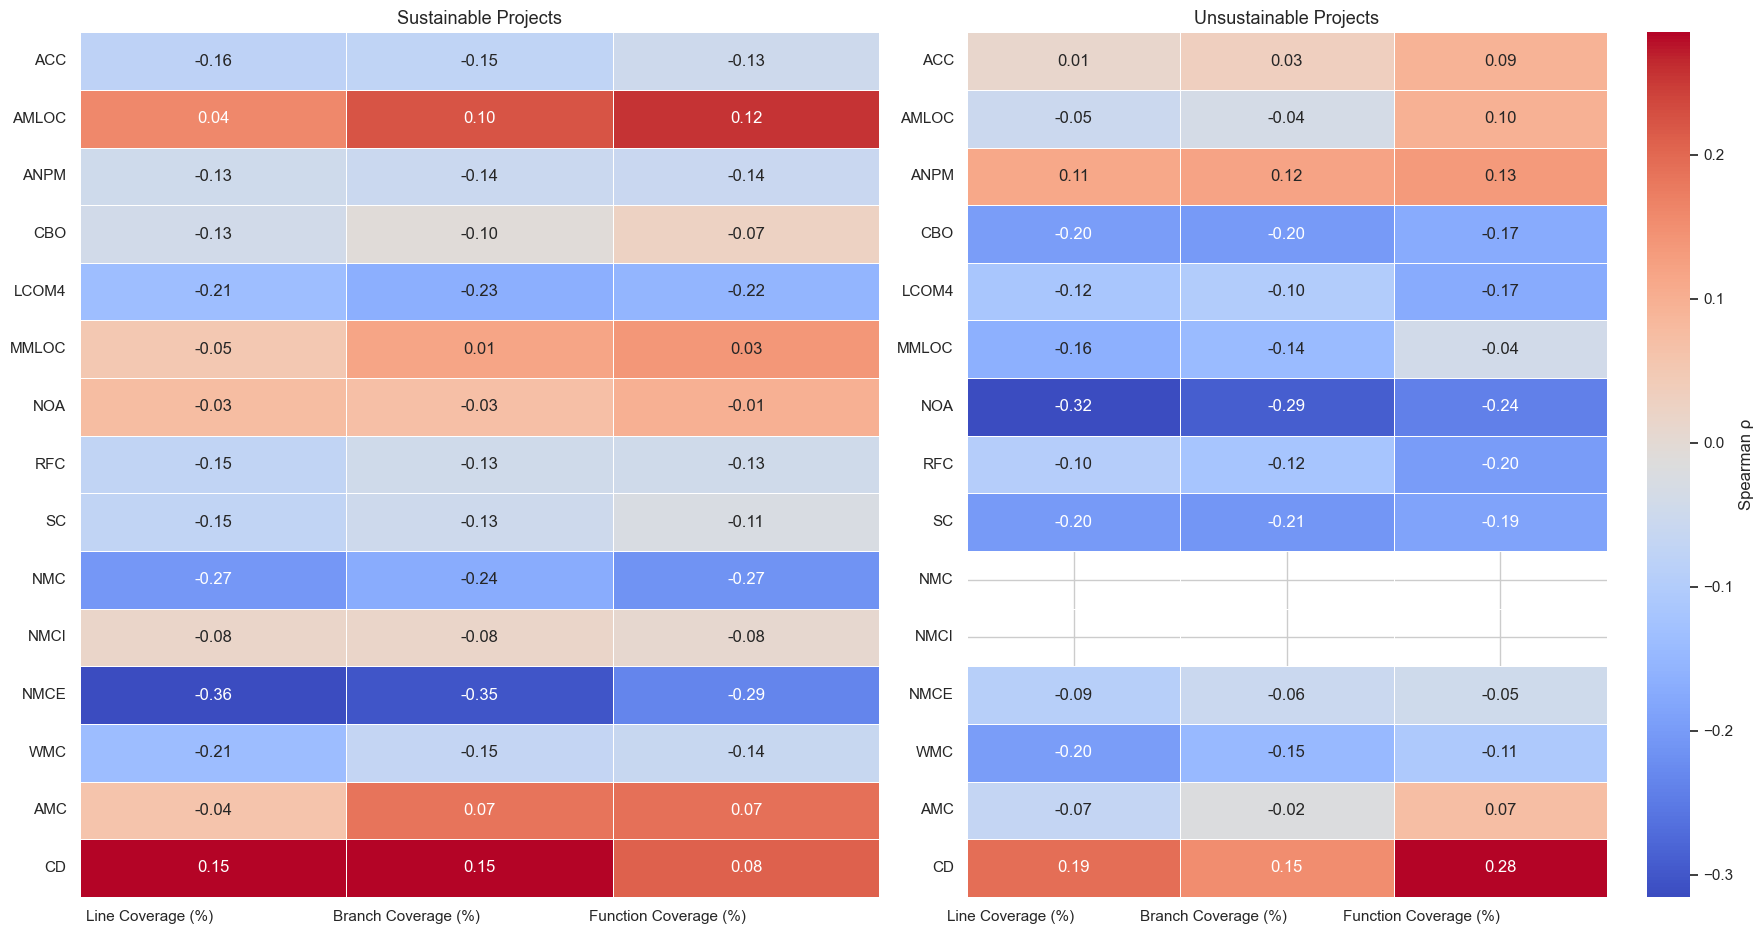

In [1434]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define your metric groups
coverage_metrics = ['line_percent', 'branch_percent', 'function_percent']
code_metrics = [
    'ACC', 'AMLOC', 'ANPM', 'CBO', 'LCOM4', 'MMLOC', 'NOA',
    'RFC', 'SC', 'NMC', 'NMCI', 'NMCE', 'WMC', 'AMC', 'Comment_Density'
]

# Filter numeric columns and compute Spearman correlation
sust_filtered = sustainable_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')
unsust_filtered = unsustainable_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')

# Compute Spearman correlation matrices and slice to only code-vs-coverage
partial_corr_sust = sust_filtered.corr(method='spearman').loc[code_metrics, coverage_metrics]
partial_corr_unsust = unsust_filtered.corr(method='spearman').loc[code_metrics, coverage_metrics]


partial_corr_sust  = partial_corr_sust.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)


partial_corr_unsust  = partial_corr_unsust.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)


# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Heatmap for Sustainable Projects
sns.heatmap(
    partial_corr_sust, ax=axes[0],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, cbar=False
)
axes[0].set_title("Sustainable Projects", fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Heatmap for Unsustainable Projects
sns.heatmap(
    partial_corr_unsust, ax=axes[1],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, cbar_kws={'label': 'Spearman ρ'}
)
axes[1].set_title("Unsustainable Projects", fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

# Layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("correlation_heatmaps_sustainable_vs_unsustainable.png", dpi=300, bbox_inches='tight')
plt.show()


# T year sustainability Test

In [8]:
selected_df=pd.read_csv("selected_df.csv")

In [9]:
selected_df

,project_url,commits_last_1_year,commits_last_2_years,commits_last_3_years,commits_last_4_years,commits_last_5_years,tf_commit,median_12_months_commits,median_24_months_commits
0,https://github.com/open-mpi/ompi,529,581,974,1027,1004,True,46.0,48.5
1,https://github.com/mfem/mfem,2190,2918,2421,3038,4920,True,193.5,218.0
2,https://github.com/LLNL/zfp,38,38,121,122,164,True,3.5,2.5
3,https://github.com/dyninst/dyninst,164,254,165,210,151,False,11.5,13.5
4,https://github.com/hypre-space/hypre,81,84,142,531,213,True,5.0,5.0
5,https://github.com/HDFGroup/hdf5,549,827,585,351,653,True,38.5,48.0
6,https://github.com/AMReX-Codes/amrex,345,431,380,556,890,True,28.0,29.5
7,https://github.com/pmodels/mpich,1032,972,1114,1726,2057,False,77.5,71.0
8,https://github.com/LLNL/sundials,196,81,69,107,67,False,9.5,7.0
9,https://github.com/xiaoyeli/superlu,49,147,68,17,20,True,1.5,3.0


## t=2, k=6

In [10]:
m=24
k=6

In [2]:
# Step 2: Apply function to extract repo names
repo_names = selected_df[selected_df[f"median_{m}_months_commits"]>=k]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()
print(processed_paths_list)
len(processed_paths_list)

NameError: name 'selected_df' is not defined

In [269]:
# Step 2: Apply function to extract repo names
repo_names = selected_df[selected_df[f"median_{m}_months_commits"]>=k]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()


df_list = []

for path in processed_paths_list:
    df_temp = pd.read_csv(path)
    df_temp['project'] = get_project_name(path)  # <-- Add project name
    df_list.append(df_temp)

sustainable_df = pd.concat(df_list, ignore_index=True)


sustainable_df['Comment_Density'] = sustainable_df['LOCCOM'] / sustainable_df['line_total']
sustainable_df

,filename,line_total,line_covered,line_percent,branch_total,branch_covered,branch_percent,function_total,function_covered,function_percent,...,SC,LOCCOM,NSM,NMC,NMCI,NMCE,WMC,AMC,project,Comment_Density
0,3rd-party/treematch/fibo.c,69,0,0.000,36,0,0.000,6,0,0.000,...,33,108,0,198,0,198,36.0,4.0,ompi,1.565217
1,3rd-party/treematch/IntConstantInitializedVect...,38,0,0.000,24,0,0.000,4,0,0.000,...,6,0,0,15,0,15,17.0,3.4,ompi,0.000000
2,3rd-party/treematch/k-partitioning.c,189,0,0.000,88,0,0.000,11,0,0.000,...,8,34,0,71,0,71,55.0,5.0,ompi,0.179894
3,3rd-party/treematch/PriorityQueue.c,114,0,0.000,40,0,0.000,19,0,0.000,...,112,4,0,33,0,33,39.9,2.1,ompi,0.035088
4,3rd-party/treematch/tm_bucket.c,364,0,0.000,159,0,0.000,18,0,0.000,...,33,27,1,278,0,278,112.2,5.1,ompi,0.074176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,SRC/single/sutil_dist.c,779,131,0.168,294,41,0.139,42,9,0.214,...,117,172,280,0,0,280,184.8,4.4,superlu_dist,0.220796
5575,TEST/dcreate_matrix.c,85,0,0.000,36,0,0.000,1,0,0.000,...,0,82,95,0,0,95,24.0,24.0,superlu_dist,0.964706
5576,TEST/pdcompute_resid.c,35,0,0.000,18,0,0.000,1,0,0.000,...,9,69,63,0,0,63,9.0,9.0,superlu_dist,1.971429
5577,TEST/pdtest.c,242,0,0.000,89,0,0.000,5,0,0.000,...,30,117,174,0,0,174,67.0,13.4,superlu_dist,0.483471


In [270]:
repo_names = selected_df[selected_df[f"median_{m}_months_commits"]<k]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()
len(processed_paths_list)

6

In [271]:
print(processed_paths_list)
df_list = []

for path in processed_paths_list:
    df_temp = pd.read_csv(path)
    df_temp['project'] = get_project_name(path)
    df_list.append(df_temp)

unsustainable_df = pd.concat(df_list, ignore_index=True)
unsustainable_df['Comment_Density'] = unsustainable_df['LOCCOM'] / unsustainable_df['line_total']

['/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/zfp/zfp_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/hypre/hypre_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/superlu/superlu_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/STRUMPACK/STRUMPACK_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/diy/diy_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/superlu_mt/superlu_mt_processed.csv']


In [272]:
unsustainable_df

,filename,line_total,line_covered,line_percent,branch_total,branch_covered,branch_percent,function_total,function_covered,function_percent,...,SC,LOCCOM,NSM,NMC,NMCI,NMCE,WMC,AMC,project,Comment_Density
0,include/zfp/array.hpp,6,6,1.000,0,0,NaN,2,2,1.000,...,20,0,5467,0,0,5467,10.8,1.2,zfp,0.000000
1,include/zfp/internal/array/exception.hpp,2,0,0.000,0,0,NaN,2,0,0.000,...,0,0,5360,0,0,5360,2.0,1.0,zfp,0.000000
2,include/zfp/internal/array/memory.hpp,35,28,0.800,8,5,0.625,21,21,1.000,...,4,0,3717,0,0,3717,27.5,2.5,zfp,0.000000
3,include/zfp/internal/array/store1.hpp,44,33,0.750,20,6,0.300,26,22,0.846,...,0,0,2,0,0,2,19.2,1.2,zfp,0.000000
4,include/zfp/internal/array/store2.hpp,49,38,0.776,24,8,0.333,28,24,0.857,...,0,0,2,0,0,2,20.4,1.2,zfp,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1506,TESTING/sp_cconvert.c,16,16,1.000,8,7,0.875,1,1,1.000,...,0,16,7,0,0,7,3.0,3.0,superlu_mt,1.000000
1507,TESTING/sp_dconvert.c,16,16,1.000,8,8,1.000,1,1,1.000,...,0,16,7,0,0,7,3.0,3.0,superlu_mt,1.000000
1508,TESTING/sp_ienv.c,14,11,0.786,9,8,0.889,1,1,1.000,...,1,64,8,0,0,8,39.0,39.0,superlu_mt,4.571429
1509,TESTING/sp_sconvert.c,16,16,1.000,8,8,1.000,1,1,1.000,...,0,16,7,0,0,7,3.0,3.0,superlu_mt,1.000000


In [273]:
metric_columns = sustainable_df.select_dtypes(include='number').columns.tolist()

# Mann-Whitney test

In [54]:
# Run statistical test and collect results
results = []
for col in metric_columns:
    s_vals = sustainable_df[col].dropna().abs()
    u_vals = unsustainable_df[col].dropna().abs()
    if not s_vals.empty and not u_vals.empty:
        stat, p = mannwhitneyu(s_vals, u_vals, alternative='two-sided')
        results.append({
            'Metric': col,
            'Sustainable_Mean': s_vals.mean(),
            'Unsustainable_Mean': u_vals.mean(),
            'U_Statistic': stat,
            'p_Value': p
        })

# Convert results to DataFrame and sort by p-value
results_df = pd.DataFrame(results).sort_values(by="p_Value")

# Print results
print(results_df.to_string(index=False))

          Metric  Sustainable_Mean  Unsustainable_Mean  U_Statistic       p_Value
             NMC        167.498297            0.001324    5780583.0 1.762526e-167
            NMCE       2130.256498         1271.041032    5589747.5  1.543360e-84
          LOCCOM         70.543287           81.833885    2860733.5  1.037406e-82
             NSM       1962.933142         1271.048974    3187475.0  1.646922e-49
 Comment_Density          0.643706            0.904434    3212594.5  4.070357e-46
             NOA          4.332318            1.473858    4948669.5  2.503561e-36
             ACC          5.944434            3.820649    3398562.5  4.134609e-36
             AMC         10.925166           18.151423    3442470.0  6.566094e-28
function_covered          5.727908            3.481800    4863017.5  4.659820e-22
             NOM         11.728267            9.172733    4772488.5  1.025422e-15
              SC         59.967198           32.861681    3658620.5  1.243534e-15
function_percent

In [55]:
significant_df = results_df[results_df["p_Value"] < 0.05]
significant_df

,Metric,Sustainable_Mean,Unsustainable_Mean,U_Statistic,p_Value
18,NMC,167.498297,0.001324,5780583.0,1.762526e-167
20,NMCE,2130.256498,1271.041032,5589747.5,1.543360e-84
16,LOCCOM,70.543287,81.833885,2860733.5,1.037406e-82
17,NSM,1962.933142,1271.048974,3187475.0,1.646922e-49
23,Comment_Density,0.643706,0.904434,3212594.5,4.070357e-46
12,NOA,4.332318,1.473858,4948669.5,2.503561e-36
9,ACC,5.944434,3.820649,3398562.5,4.134609e-36
22,AMC,10.925166,18.151423,3442470.0,6.566094e-28
7,function_covered,5.727908,3.481800,4863017.5,4.659820e-22
13,NOM,11.728267,9.172733,4772488.5,1.025422e-15


In [56]:
# Calculate the mean difference
results_df["Mean_Difference"] = results_df["Sustainable_Mean"] - results_df["Unsustainable_Mean"]

# Filter for positively correlated metrics with statistically significant difference
positively_correlated = results_df[(results_df["Mean_Difference"] > 0) & (results_df["p_Value"] < 0.05)]
positively_correlated["Metric"]

18                 NMC
20                NMCE
17                 NSM
12                 NOA
9                  ACC
7     function_covered
13                 NOM
15                  SC
8     function_percent
10                 CBO
6       function_total
4       branch_covered
3         branch_total
1         line_covered
0           line_total
2         line_percent
19                NMCI
14                 RFC
21                 WMC
Name: Metric, dtype: object

In [57]:
negatively_correlated = results_df[(results_df["Mean_Difference"] < 0) & (results_df["p_Value"] < 0.05)]
negatively_correlated

,Metric,Sustainable_Mean,Unsustainable_Mean,U_Statistic,p_Value,Mean_Difference
16,LOCCOM,70.543287,81.833885,2860733.5,1.037406e-82,-11.290598
23,Comment_Density,0.643706,0.904434,3212594.5,4.070357e-46,-0.260728
22,AMC,10.925166,18.151423,3442470.0,6.566094e-28,-7.226257
11,LCOM4,6.711418,6.956320,4477915.0,7.272791e-05,-0.244903


## Cliff's delta

In [58]:
results = []

for col in metric_columns:
    x1 = sustainable_df[col].dropna().abs()
    x2 = unsustainable_df[col].dropna().abs()


    if x1.empty or x2.empty:
        continue

    d, res = cliffs_delta(x1, x2)
    results.append({
        "Metric": col,
        "Cliffs_Delta": round(d, 4),
        "Effect_Size": res
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

              Metric  Cliffs_Delta Effect_Size
0         line_total       -0.0790  negligible
1       line_covered        0.0933  negligible
2       line_percent        0.0727  negligible
3       branch_total        0.1013  negligible
4     branch_covered        0.0993  negligible
5     branch_percent        0.0306  negligible
6     function_total        0.1084  negligible
7   function_covered        0.1538       small
8   function_percent        0.1205  negligible
9                ACC       -0.1937       small
10               CBO       -0.1163  negligible
11             LCOM4        0.0624  negligible
12               NOA        0.1741       small
13               NOM        0.1323  negligible
14               RFC       -0.0438  negligible
15                SC       -0.1320  negligible
16            LOCCOM       -0.3213       small
17               NSM       -0.2438       small
18               NMC        0.3715      medium
19              NMCI        0.0115  negligible
20           

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remove unwanted metrics
results_df = results_df[~results_df["Metric"].isin(["branch_covered", "line_covered","function_covered","NOM","NSM"])]

# Rename percent metrics for better labels
results_df["Metric"] = results_df["Metric"].replace({
    "branch_percent": "BC",
    "line_percent": "LC",
    "function_percent": "FC",
    "branch_total": "NOB",
    "line_total": "LOC",
    "Comment_Density":"CD",
    "function_total":"NOM"
})

# Sort metrics by Cliff's Delta
results_df = results_df.sort_values("Cliffs_Delta")

# Set style and figure
sns.set(style="whitegrid", font_scale=0.8)
plt.figure(figsize=(10, 8))

# Horizontal bar plot with reduced width
sns.barplot(
    x="Cliffs_Delta",
    y="Metric",
    data=results_df,
    color="gray",
    width=0.5
)

# Add vertical lines for Cliff’s Delta thresholds (effect sizes)
for threshold in [0.147, 0.33, 0.474]:
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=-threshold, color='black', linestyle='--', linewidth=0.8)

# Adjust x-axis range to fit data with margin
min_val = results_df["Cliffs_Delta"].min()
max_val = results_df["Cliffs_Delta"].max()
plt.xlim(min_val - 0.1, max_val + 0.1)  # 0.1 is margin

# Set custom x-axis ticks and labels
plt.xticks(
    ticks=[-0.474, -0.33, -0.147, 0, 0.147, 0.33, 0.474],
    labels=["Large", "Med", "Small", "0", "Small", "Med", "Large"],
    fontsize=14
)

# Y-axis (metrics)
plt.yticks(fontsize=14)

# Axis labels and title
plt.xlabel("Cliff's Delta", fontsize=14)
plt.ylabel("Metric", fontsize=14)
# plt.title("Cliff's Delta by Metric", fontsize=14)

# Layout
plt.tight_layout()
plt.savefig("cliffs_delta_for_tyear.png", dpi=300, bbox_inches='tight')  # or use .pdf
plt.show()


Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Compute Spearman correlation
spearman_corr = sustainable_df.select_dtypes(include=['number']).corr(method='spearman')
# Keep only upper triangle
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
spearman_pairs = spearman_corr.where(mask).stack().reset_index()
spearman_pairs.columns = ['Metric1', 'Metric2', 'Spearman']
strong = spearman_pairs[spearman_pairs['Spearman'].abs() > 0.5].sort_values(by='Spearman', ascending=False)
strong 

In [ ]:
# Compute Spearman correlation
spearman_corr = unsustainable_df.select_dtypes(include=['number']).corr(method='spearman')
# Keep only upper triangle
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
spearman_pairs = spearman_corr.where(mask).stack().reset_index()
spearman_pairs.columns = ['Metric1', 'Metric2', 'Spearman']
strong = spearman_pairs[spearman_pairs['Spearman'].abs() > 0.5].sort_values(by='Spearman', ascending=False)
strong 

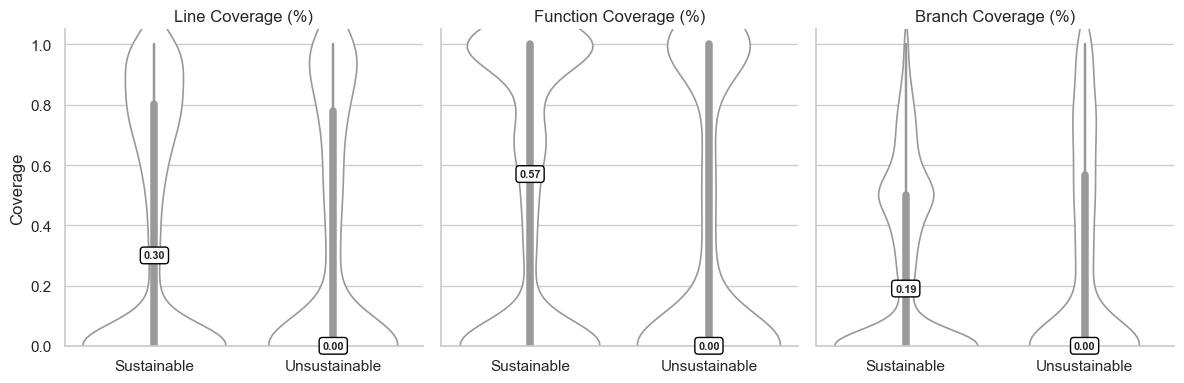

In [282]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define the 3 metrics
metrics = [
    ("line_percent", "Line Coverage (%)"),
    ("function_percent", "Function Coverage (%)"),
    ("branch_percent", "Branch Coverage (%)")
]

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (metric, label) in zip(axes, metrics):
    # Prepare combined data
    df = pd.DataFrame({
        "Coverage": pd.concat([
            sustainable_df[metric],
            unsustainable_df[metric]
        ], ignore_index=True),
        "Status": ["Sustainable"] * len(sustainable_df) + ["Unsustainable"] * len(unsustainable_df)
    })

    # Draw violin + box
    sns.violinplot(x="Status", y="Coverage", data=df,
                   inner="box", ax=ax, color="white", linewidth=1.2)

    # Annotate medians
    for i, group in enumerate(["Sustainable", "Unsustainable"]):
        median_val = round(df[df["Status"] == group]["Coverage"].median(), 2)
        ax.text(i, median_val, f"{median_val:.2f}",
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    if ax == axes[0]:
        ax.set_ylabel("Coverage")
    else:
        ax.set_ylabel("")
plt.savefig("tyear_coverage_sustainable_vs_unsustainable.png", dpi=300, bbox_inches='tight')
sns.despine()
plt.tight_layout()
plt.show()

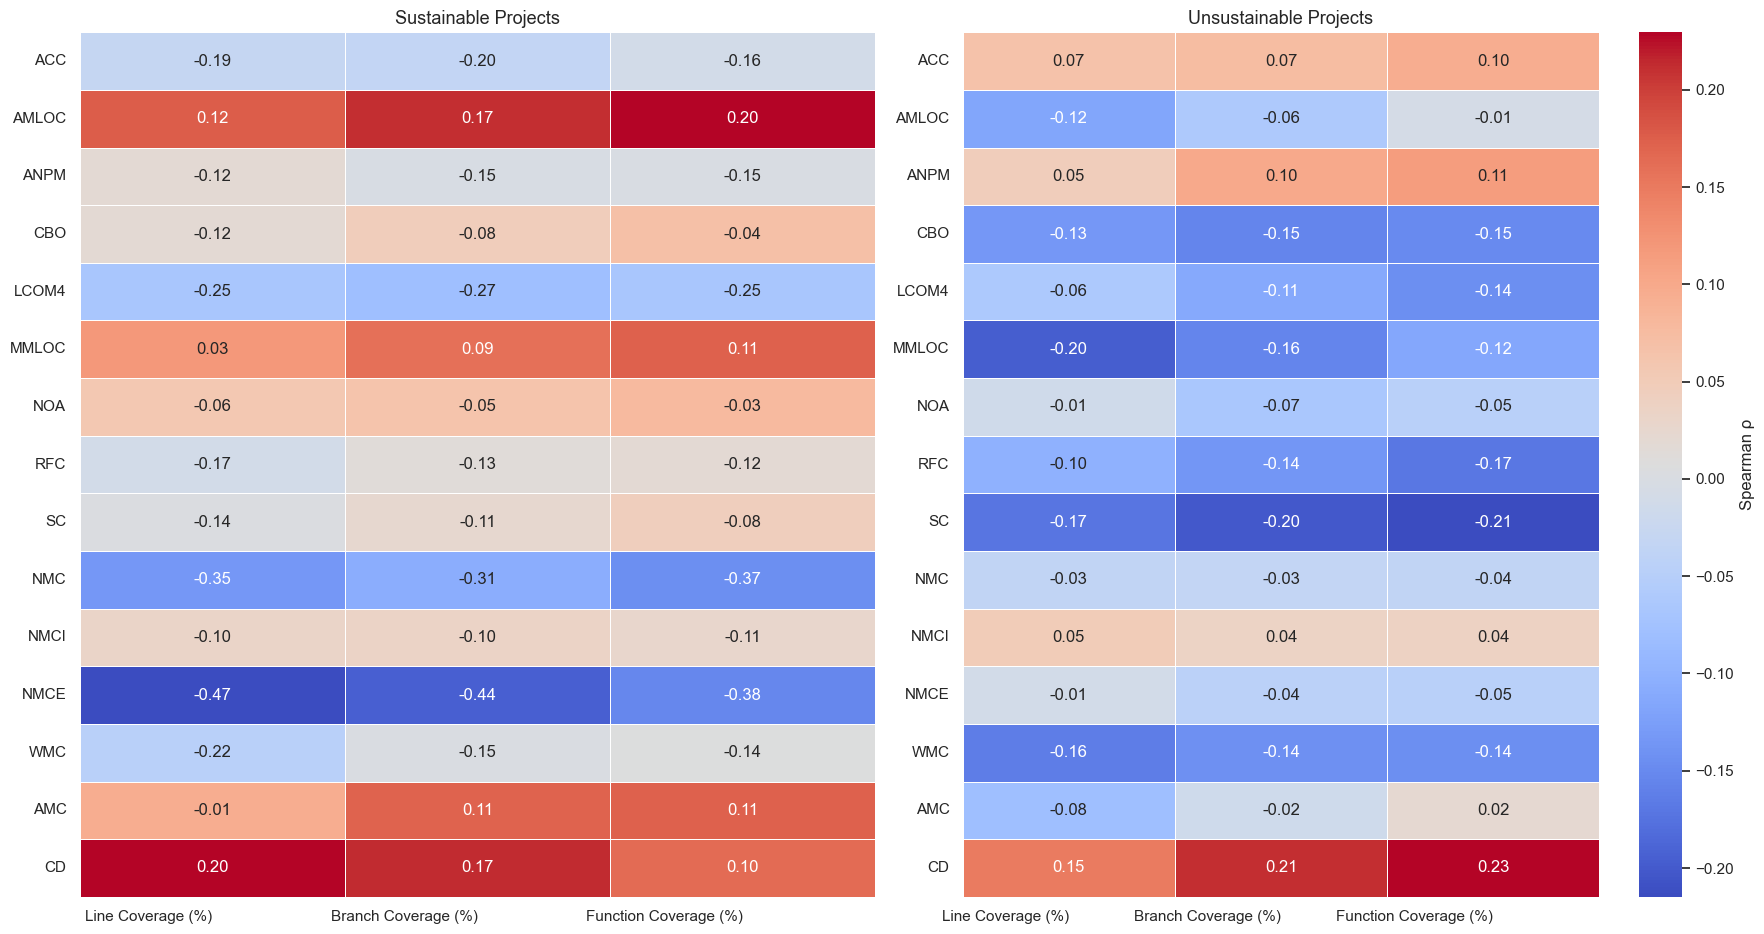

In [1061]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define your metric groups
coverage_metrics = ['line_percent', 'branch_percent', 'function_percent']
code_metrics = [
    'ACC', 'AMLOC', 'ANPM', 'CBO', 'LCOM4', 'MMLOC', 'NOA',
    'RFC', 'SC', 'NMC', 'NMCI', 'NMCE', 'WMC', 'AMC', 'Comment_Density'
]

# Filter numeric columns and compute Spearman correlation
sust_filtered = sustainable_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')
unsust_filtered = unsustainable_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')

# Compute Spearman correlation matrices and slice to only code-vs-coverage
partial_corr_sust = sust_filtered.corr(method='spearman').loc[code_metrics, coverage_metrics]
partial_corr_unsust = unsust_filtered.corr(method='spearman').loc[code_metrics, coverage_metrics]

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 10))


partial_corr_sust = partial_corr_sust.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)

partial_corr_unsust  = partial_corr_unsust.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)

# Heatmap for Sustainable Projects
sns.heatmap(
    partial_corr_sust, ax=axes[0],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, cbar=False
)


axes[0].set_title("Sustainable Projects", fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Heatmap for Unsustainable Projects
sns.heatmap(
    partial_corr_unsust, ax=axes[1],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, cbar_kws={'label': 'Spearman ρ'}
)
axes[1].set_title("Unsustainable Projects", fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

# Layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("tyear_correlation_heatmaps_sustainable_vs_unsustainable.png", dpi=300, bbox_inches='tight')
plt.show()


# Classificaiton using truck factor

In [458]:
from pydriller import Repository
from collections import defaultdict
from datetime import datetime, timedelta
import math
import os
from datetime import timezone

# === CONFIG ===
DOA_K = 0.75                    # Normalized DOA threshold
DOA_M = 3.293                   # Minimum absolute DOA
ONE_YEAR = timedelta(days=365)
CLONE_DIR = "/Users/mushfiq344/ORNL/git_repos"   # Change this to a writable path

def calculate_doa(first_author, dev, dev_mods, others_mods):
    FA = 1 if dev == first_author else 0
    DL = dev_mods
    AC = others_mods
    return 3.293 + 1.098 * FA + 0.164 * DL - 0.321 * math.log(1 + AC)

def estimate_tf(repo_url):
    file_mods = defaultdict(list)                  # filepath -> list of (author, date)
    author_last_commit = defaultdict(lambda: datetime.min.replace(tzinfo=timezone.utc))


    print(f"\n[+] Analyzing repository: {repo_url}")
    try:
        commits = list(Repository(
            repo_url,
            clone_repo_to=CLONE_DIR,
        ).traverse_commits())
    except Exception as e:
        print(f"[!] Failed to access repository: {e}")
        return 0, [], False

    if not commits:
        print("[!] No commits found.")
        return 0, [], False

    latest_date = max(c.committer_date for c in commits)
    print(f"total commits {len(commits)}")
    for commit in commits:
        try:
            for mf in commit.modified_files:
                if mf.new_path and mf.change_type.name != "DELETE":
                    file_mods[mf.new_path].append((commit.author.name, commit.committer_date))
                    author_last_commit[commit.author.name] = max(
                        author_last_commit[commit.author.name], commit.committer_date
                    )
        except Exception as e:
            print(f"[!] Skipping commit {commit.hash} due to error: {e}")

    print("done iterating comments")

    # Step 1: Calculate DOA per file per author
    file_authors = defaultdict(dict)  # file -> author -> DOA
    for file, mods in file_mods.items():
        dev_mod_counts = defaultdict(int)
        for dev, _ in mods:
            dev_mod_counts[dev] += 1

        for dev in dev_mod_counts:
            others_mods = sum(dev_mod_counts.values()) - dev_mod_counts[dev]
            doa = calculate_doa(mods[0][0], dev, dev_mod_counts[dev], others_mods)
            file_authors[file][dev] = doa

    # Step 2: Normalize DOA and assign file authors
    author_files = defaultdict(set)  # author -> set of files they "own"
    for file, devs in file_authors.items():
        max_doa = max(devs.values())
        for dev, doa in devs.items():
            norm_doa = doa / max_doa if max_doa != 0 else 0
            if norm_doa >= DOA_K and doa >= DOA_M:
                author_files[dev].add(file)

    total_files = set(file_authors.keys())

    # Step 3: Estimate Truck Factor
    tf = 0
    tf_authors = []
    remaining_authors = dict(author_files)  # shallow copy

    while remaining_authors:
        covered_files = set()
        for files in remaining_authors.values():
            covered_files.update(files)

        coverage = len(covered_files) / len(total_files)
        if coverage < 0.5:
            break

        # Remove top author (most file coverage)
        top_author = max(remaining_authors.items(), key=lambda x: len(x[1]))[0]
        tf_authors.append(top_author)
        del remaining_authors[top_author]
        tf += 1

    # Step 4: Check if any TF author has committed in last 1 year
    active = any(
        (latest_date - author_last_commit[author]) <= ONE_YEAR
        for author in tf_authors
    )

    return tf, tf_authors, active


# === Example usage ===
if __name__ == "__main__":
    repo = "https://github.com/xiaoyeli/superlu_mt"  # replace as needed
    tf, tf_authors, active = estimate_tf(repo)

    print(f"\n[✓] Estimated Truck Factor: {tf}")
    print(f"[✓] TF Developers: {tf_authors}")
    print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")



[+] Analyzing repository: https://github.com/xiaoyeli/superlu_mt
total commits 62
done iterating comments

[✓] Estimated Truck Factor: 1
[✓] TF Developers: ['xiaoye']
[✓] At least one TF dev active in past year? No


In [459]:
repo = "https://github.com/xiaoyeli/superlu_dist"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/xiaoyeli/superlu_dist
total commits 1478


KeyboardInterrupt: 

In [115]:
repo = "https://github.com/diatomic/diy"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/diatomic/diy
total commits 891
done iterating comments

[✓] Estimated Truck Factor: 1
[✓] TF Developers: ['Dmitriy Morozov']
[✓] At least one TF dev active in past year? Yes


In [118]:
repo = "https://github.com/xiaoyeli/superlu"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/xiaoyeli/superlu
total commits 368
done iterating comments

[✓] Estimated Truck Factor: 2
[✓] TF Developers: ['xiaoye', 'Sherry Li']
[✓] At least one TF dev active in past year? Yes


In [120]:
repo = "https://github.com/LLNL/sundials"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/LLNL/sundials
total commits 6974
done iterating comments

[✓] Estimated Truck Factor: 2
[✓] TF Developers: ['radu', 'Gardner, David James']
[✓] At least one TF dev active in past year? No


In [121]:
repo = "https://github.com/pmodels/mpich"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/pmodels/mpich
total commits 20877
done iterating comments

[✓] Estimated Truck Factor: 1
[✓] TF Developers: ['Pavan Balaji']
[✓] At least one TF dev active in past year? No


In [122]:
repo = "https://github.com/HDFGroup/hdf5"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/HDFGroup/hdf5
total commits 24041
done iterating comments

[✓] Estimated Truck Factor: 3
[✓] TF Developers: ['Allen Byrne', 'Quincey Koziol', 'Scott Wegner']
[✓] At least one TF dev active in past year? Yes


In [124]:
print("hello")

hello


In [125]:
repo = "https://github.com/hypre-space/hypre"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/hypre-space/hypre
total commits 12337
done iterating comments

[✓] Estimated Truck Factor: 3
[✓] TF Developers: ['painter', 'Rob Falgout', 'chtong']
[✓] At least one TF dev active in past year? Yes


In [126]:
repo = "https://github.com/dyninst/dyninst"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/dyninst/dyninst
total commits 21220
done iterating comments

[✓] Estimated Truck Factor: 5
[✓] TF Developers: ['Andrew Bernat', 'bill', 'bernat', 'Matthew Legendre', 'Sunny Shah']
[✓] At least one TF dev active in past year? No


In [127]:
repo = "https://github.com/LLNL/zfp"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/LLNL/zfp
total commits 1146
done iterating comments

[✓] Estimated Truck Factor: 2
[✓] TF Developers: ['Markus Salasoo', 'lindstro']
[✓] At least one TF dev active in past year? Yes


In [128]:
repo = "https://github.com/open-mpi/ompi"  # replace as needed
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/open-mpi/ompi
total commits 34912
done iterating comments

[✓] Estimated Truck Factor: 3
[✓] TF Developers: ['Jeff Squyres', 'Ralph Castain', 'Gilles Gouaillardet']
[✓] At least one TF dev active in past year? Yes


In [275]:
repo = "https://github.com/pghysels/STRUMPACK"
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/pghysels/STRUMPACK
total commits 2110
done iterating comments

[✓] Estimated Truck Factor: 1
[✓] TF Developers: ['Pieter Ghysels']
[✓] At least one TF dev active in past year? Yes


In [277]:
repo = "https://github.com/mfem/mfem"
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/mfem/mfem
total commits 24273
done iterating comments

[✓] Estimated Truck Factor: 7
[✓] TF Developers: ['camierjs', 'Tzanio', 'Tzanio Kolev', 'Stowell, Mark L', 'Will Pazner', 'Yohann Dudouit', 'Aaron Fisher']
[✓] At least one TF dev active in past year? Yes


In [278]:
repo = "https://github.com/AMReX-Codes/amrex"
tf, tf_authors, active = estimate_tf(repo)

print(f"\n[✓] Estimated Truck Factor: {tf}")
print(f"[✓] TF Developers: {tf_authors}")
print(f"[✓] At least one TF dev active in past year? {'Yes' if active else 'No'}")


[+] Analyzing repository: https://github.com/AMReX-Codes/amrex
total commits 27456
done iterating comments

[✓] Estimated Truck Factor: 4
[✓] TF Developers: ['Weiqun Zhang', 'Christopher Degrendele', 'Ann Almgren', 'Tan Nguyen']
[✓] At least one TF dev active in past year? Yes


In [279]:
selected_df["tf_commit"]=[True,True,True,False,True,True,True,False,False,True,False,True,True,False]

/var/folders/j3/ksjvw7w15pxb38r8w1yqctl00000gr/T/ipykernel_52938/2526006561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["tf_commit"]=[True,True,True,False,True,True,True,False,False,True,False,True,True,False]


In [460]:
selected_df

,project_url,commits_last_1_year,commits_last_2_years,commits_last_3_years,commits_last_4_years,commits_last_5_years,tf_commit,median_12_months_commits,median_24_months_commits
2,https://github.com/open-mpi/ompi,529,581,974,1027,1004,True,46.0,48.5
4,https://github.com/mfem/mfem,2190,2918,2421,3038,4920,True,193.5,218.0
7,https://github.com/LLNL/zfp,38,38,121,122,164,True,3.5,2.5
8,https://github.com/dyninst/dyninst,164,254,165,210,151,False,11.5,13.5
9,https://github.com/hypre-space/hypre,81,84,142,531,213,True,5.0,5.0
10,https://github.com/HDFGroup/hdf5,549,827,585,351,653,True,38.5,48.0
12,https://github.com/AMReX-Codes/amrex,345,431,380,556,890,True,28.0,29.5
13,https://github.com/pmodels/mpich,1032,972,1114,1726,2057,False,77.5,71.0
14,https://github.com/LLNL/sundials,196,81,69,107,67,False,9.5,7.0
20,https://github.com/xiaoyeli/superlu,49,147,68,17,20,True,1.5,3.0


In [132]:
selected_df.to_csv("selected_df.csv",index=False)

# TF starts here

In [74]:
# Step 2: Apply function to extract repo names
repo_names = selected_df[selected_df["tf_commit"]==True]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()
print(len(processed_paths_list))
df_list = [pd.read_csv(f) for f in processed_paths_list]
sustainable_df = pd.concat(df_list, ignore_index=True)
sustainable_df['Comment_Density'] = sustainable_df['LOCCOM'] / sustainable_df['line_total']
sustainable_df

9


,filename,line_total,line_covered,line_percent,branch_total,branch_covered,branch_percent,function_total,function_covered,function_percent,...,RFC,SC,LOCCOM,NSM,NMC,NMCI,NMCE,WMC,AMC,Comment_Density
0,3rd-party/treematch/fibo.c,69,0,0.0,36,0,0.0,6,0,0.0,...,52,33,108,0,198,0,198,36.0,4.0,1.565217
1,3rd-party/treematch/IntConstantInitializedVect...,38,0,0.0,24,0,0.0,4,0,0.0,...,28,6,0,0,15,0,15,17.0,3.4,0.000000
2,3rd-party/treematch/k-partitioning.c,189,0,0.0,88,0,0.0,11,0,0.0,...,42,8,34,0,71,0,71,55.0,5.0,0.179894
3,3rd-party/treematch/PriorityQueue.c,114,0,0.0,40,0,0.0,19,0,0.0,...,146,112,4,0,33,0,33,39.9,2.1,0.035088
4,3rd-party/treematch/tm_bucket.c,364,0,0.0,159,0,0.0,18,0,0.0,...,116,33,27,1,278,0,278,112.2,5.1,0.074176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3300,examples/reduce/merge-reduce.cpp,114,0,0.0,154,0,0.0,14,0,0.0,...,41,21,0,11588,0,0,11588,24.0,2.0,0.000000
3301,examples/load_balancing/common.hpp,83,0,0.0,50,0,0.0,13,0,0.0,...,47,44,0,10683,0,0,10683,28.6,2.2,0.000000
3302,examples/reduce/all-to-all.cpp,89,0,0.0,202,0,0.0,4,0,0.0,...,41,38,0,11613,0,0,11613,15.0,5.0,0.000000
3303,examples/decomposition/regular-decomposer-long...,52,0,0.0,74,0,0.0,6,0,0.0,...,123,185,0,10062,0,0,10062,5.0,1.0,0.000000


In [ ]:
processed_paths_list

In [75]:
repo_names = selected_df[selected_df["tf_commit"]==False]['project_url'].apply(get_repo_name)

# Step 3: Add prefix and suffix outside the function
prefix = "/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/"
suffix = "_processed.csv"

processed_paths = prefix + repo_names + "/" + repo_names + suffix

# Convert to list if needed
processed_paths_list = processed_paths.tolist()
print(processed_paths_list)
df_list = [pd.read_csv(f) for f in processed_paths_list]
unsustainable_df = pd.concat(df_list, ignore_index=True)
unsustainable_df['Comment_Density'] = unsustainable_df['LOCCOM'] / unsustainable_df['line_total']
unsustainable_df

['/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/dyninst/dyninst_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/mpich/mpich_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/sundials/sundials_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/superlu_dist/superlu_dist_processed.csv', '/Users/srahma14/Library/CloudStorage/OneDrive-UniversityofTennessee/ORNL/Scientific_Projects/superlu_mt/superlu_mt_processed.csv']


,filename,line_total,line_covered,line_percent,branch_total,branch_covered,branch_percent,function_total,function_covered,function_percent,...,RFC,SC,LOCCOM,NSM,NMC,NMCI,NMCE,WMC,AMC,Comment_Density
0,common/h/Architecture.h,13,0,0.000,4,0,0.000,1,0,0.0,...,2,1,0,11,0,0,11,12.0,12.0,0.000000
1,common/h/IBSTree-fast.h,69,0,0.000,123,0,0.000,13,0,0.0,...,11,0,0,0,0,0,0,33.6,2.8,0.000000
2,common/h/ProcReader.h,3,0,0.000,0,0,NaN,1,0,0.0,...,6,0,0,10434,0,0,10434,2.0,1.0,0.000000
3,common/h/registers/x86_regs.h,2,0,0.000,2,0,0.000,0,0,NaN,...,138,0,0,0,0,0,0,1.0,1.0,0.000000
4,common/h/unaligned_memory_access.h,9,2,0.222,106,5,0.047,0,0,NaN,...,0,0,0,15,0,0,15,6.0,1.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3780,TESTING/sp_cconvert.c,16,16,1.000,8,7,0.875,1,1,1.0,...,1,0,16,7,0,0,7,3.0,3.0,1.000000
3781,TESTING/sp_dconvert.c,16,16,1.000,8,8,1.000,1,1,1.0,...,1,0,16,7,0,0,7,3.0,3.0,1.000000
3782,TESTING/sp_ienv.c,14,11,0.786,9,8,0.889,1,1,1.0,...,2,1,64,8,0,0,8,39.0,39.0,4.571429
3783,TESTING/sp_sconvert.c,16,16,1.000,8,8,1.000,1,1,1.0,...,1,0,16,7,0,0,7,3.0,3.0,1.000000


In [1449]:
# Run statistical test and collect results
results = []
for col in metric_columns:
    s_vals = sustainable_df[col].dropna().abs()
    u_vals = unsustainable_df[col].dropna().abs()
    if not s_vals.empty and not u_vals.empty:
        stat, p = mannwhitneyu(s_vals, u_vals, alternative='two-sided')
        results.append({
            'Metric': col,
            'Sustainable_Mean': s_vals.mean(),
            'Unsustainable_Mean': u_vals.mean(),
            'U_Statistic': stat,
            'p_Value': p
        })

# Convert results to DataFrame and sort by p-value
results_df = pd.DataFrame(results).sort_values(by="p_Value")

# Print results
print(results_df.to_string(index=False))

          Metric  Sustainable_Mean  Unsustainable_Mean  U_Statistic       p_Value
              SC         84.290772           27.907530    9749013.5  0.000000e+00
             CBO          9.783359            3.309379    9652847.5  0.000000e+00
             RFC         79.951891           34.370145    8725204.5 6.517653e-182
             ACC          9.182148            2.269485    8096686.5 1.824764e-119
            NMCE       2452.769138         1505.638573    7992208.5  7.613160e-91
          LOCCOM        111.219970           39.532365    7792912.0  3.705237e-72
  function_total         18.669289            7.274505    7603578.0  4.110359e-57
           LCOM4          8.558245            5.196565    7500528.5  1.063954e-53
             NOM         14.080787            8.653897    7436816.5  2.550649e-44
 Comment_Density          0.893388            0.529773    7373480.5  5.370129e-39
             NOA          4.505295            3.040159    7099715.0  1.194976e-32
             NSM

In [1450]:
significant_df = results_df[results_df["p_Value"] < 0.05]
significant_df

,Metric,Sustainable_Mean,Unsustainable_Mean,U_Statistic,p_Value
15,SC,84.290772,27.907530,9749013.5,0.000000e+00
10,CBO,9.783359,3.309379,9652847.5,0.000000e+00
14,RFC,79.951891,34.370145,8725204.5,6.517653e-182
9,ACC,9.182148,2.269485,8096686.5,1.824764e-119
20,NMCE,2452.769138,1505.638573,7992208.5,7.613160e-91
16,LOCCOM,111.219970,39.532365,7792912.0,3.705237e-72
6,function_total,18.669289,7.274505,7603578.0,4.110359e-57
11,LCOM4,8.558245,5.196565,7500528.5,1.063954e-53
13,NOM,14.080787,8.653897,7436816.5,2.550649e-44
23,Comment_Density,0.893388,0.529773,7373480.5,5.370129e-39


In [1451]:
# Calculate the mean difference
results_df["Mean_Difference"] = results_df["Sustainable_Mean"] - results_df["Unsustainable_Mean"]

# Filter for positively correlated metrics with statistically significant difference
positively_correlated = results_df[(results_df["Mean_Difference"] > 0) & (results_df["p_Value"] < 0.05)]
positively_correlated["Metric"]

15                  SC
10                 CBO
14                 RFC
9                  ACC
20                NMCE
16              LOCCOM
6       function_total
11               LCOM4
13                 NOM
23     Comment_Density
12                 NOA
17                 NSM
1         line_covered
4       branch_covered
21                 WMC
7     function_covered
0           line_total
3         branch_total
Name: Metric, dtype: object

In [1452]:
negatively_correlated = results_df[(results_df["Mean_Difference"] < 0) & (results_df["p_Value"] < 0.05)]
negatively_correlated

,Metric,Sustainable_Mean,Unsustainable_Mean,U_Statistic,p_Value,Mean_Difference
5,branch_percent,0.231499,0.305965,4573873.5,9.443262e-28,-0.074466
2,line_percent,0.331480,0.430140,5373420.5,3.160833e-27,-0.098660
8,function_percent,0.428480,0.511202,5344118.0,2.664865e-18,-0.082721
22,AMC,10.972950,13.768217,5805101.0,1.672536e-07,-2.795267
19,NMCI,0.071407,0.140555,6298385.0,6.402637e-03,-0.069148


# Cliff's delta

In [1453]:
results = []

for col in metric_columns:
    x1 = sustainable_df[col].dropna().abs()
    x2 = unsustainable_df[col].dropna().abs()


    if x1.empty or x2.empty:
        continue

    d, res = cliffs_delta(x1, x2)
    results.append({
        "Metric": col,
        "Cliffs_Delta": round(d, 4),
        "Effect_Size": res
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

              Metric  Cliffs_Delta Effect_Size
0         line_total        0.0648  negligible
1       line_covered       -0.0903  negligible
2       line_percent       -0.1409  negligible
3       branch_total        0.0399  negligible
4     branch_covered       -0.0834  negligible
5     branch_percent       -0.1484       small
6     function_total        0.2157       small
7   function_covered        0.0655  negligible
8   function_percent       -0.1138  negligible
9                ACC        0.2945       small
10               CBO        0.5433       large
11             LCOM4        0.1992       small
12               NOA        0.1351  negligible
13               NOM        0.1890       small
14               RFC        0.3950      medium
15                SC        0.5587       large
16            LOCCOM        0.2459       small
17               NSM        0.1599       small
18               NMC        0.0197  negligible
19              NMCI        0.0070  negligible
20           

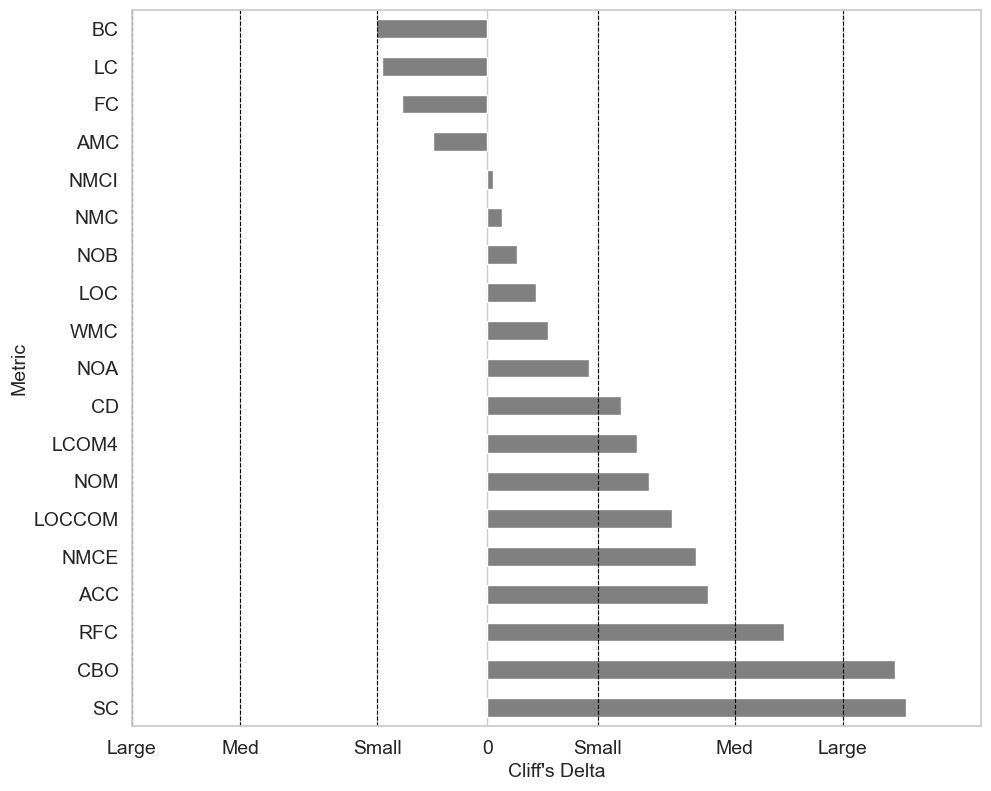

In [1454]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remove unwanted metrics
results_df = results_df[~results_df["Metric"].isin(["branch_covered", "line_covered","function_covered","NOM","NSM"])]

# Rename percent metrics for better labels
results_df["Metric"] = results_df["Metric"].replace({
    "branch_percent": "BC",
    "line_percent": "LC",
    "function_percent": "FC",
    "branch_total": "NOB",
    "line_total": "LOC",
    "Comment_Density":"CD",
    "function_total":"NOM"
})

# Sort metrics by Cliff's Delta
results_df = results_df.sort_values("Cliffs_Delta")

# Set style and figure
sns.set(style="whitegrid", font_scale=0.8)
plt.figure(figsize=(10, 8))

# Horizontal bar plot with reduced width
sns.barplot(
    x="Cliffs_Delta",
    y="Metric",
    data=results_df,
    color="gray",
    width=0.5
)

# Add vertical lines for Cliff’s Delta thresholds (effect sizes)
for threshold in [0.147, 0.33, 0.474]:
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=-threshold, color='black', linestyle='--', linewidth=0.8)

# Adjust x-axis range to fit data with margin
min_val = results_df["Cliffs_Delta"].min()
max_val = results_df["Cliffs_Delta"].max()
plt.xlim(min_val - 0.1, max_val + 0.1)  # 0.1 is margin

# Set custom x-axis ticks and labels
plt.xticks(
    ticks=[-0.474, -0.33, -0.147, 0, 0.147, 0.33, 0.474],
    labels=["Large", "Med", "Small", "0", "Small", "Med", "Large"],
    fontsize=14
)

# Y-axis (metrics)
plt.yticks(fontsize=14)

# Axis labels and title
plt.xlabel("Cliff's Delta", fontsize=14)
plt.ylabel("Metric", fontsize=14)
#plt.title("Cliff's Delta by Metric", fontsize=14)

# Layout
plt.tight_layout()
plt.savefig("cliffs_delta_for_tf.png", dpi=300, bbox_inches='tight')  # or use .pdf
plt.show()


# Spearman corelation

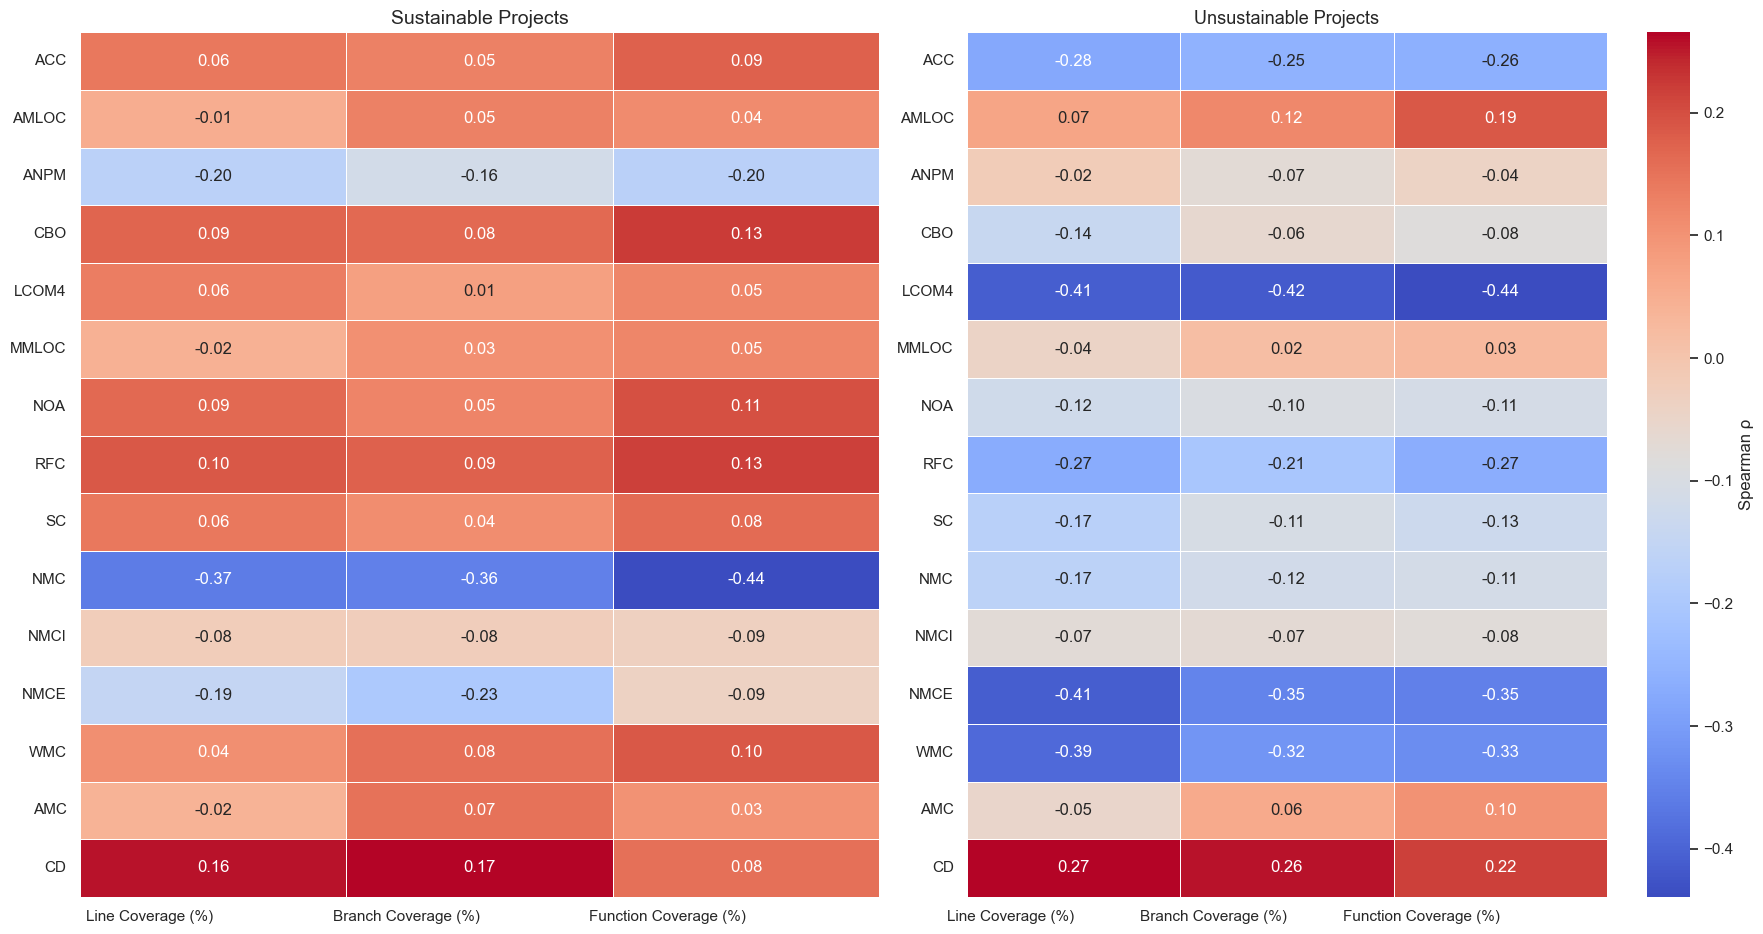

In [1241]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define your metric groups
coverage_metrics = ['line_percent', 'branch_percent', 'function_percent']
code_metrics = [
    'ACC', 'AMLOC', 'ANPM', 'CBO', 'LCOM4', 'MMLOC', 'NOA',
    'RFC', 'SC', 'NMC', 'NMCI', 'NMCE', 'WMC', 'AMC', 'Comment_Density'
]

# Filter numeric columns and compute Spearman correlation
sust_filtered = sustainable_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')
unsust_filtered = unsustainable_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')

# Compute Spearman correlation matrices and slice to only code-vs-coverage
partial_corr_sust = sust_filtered.corr(method='spearman').loc[code_metrics, coverage_metrics]
partial_corr_unsust = unsust_filtered.corr(method='spearman').loc[code_metrics, coverage_metrics]

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

partial_corr_sust = partial_corr_sust.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)

partial_corr_unsust  = partial_corr_unsust.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)


# Heatmap for Sustainable Projects
sns.heatmap(
    partial_corr_sust, ax=axes[0],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, cbar=False
)
axes[0].set_title("Sustainable Projects", fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Heatmap for Unsustainable Projects
sns.heatmap(
    partial_corr_unsust, ax=axes[1],
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, cbar_kws={'label': 'Spearman ρ'}
)
axes[1].set_title("Unsustainable Projects", fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

# Layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("tyear_correlation_heatmaps_sustainable_vs_unsustainable.png", dpi=300, bbox_inches='tight')
plt.show()


/var/folders/j3/ksjvw7w15pxb38r8w1yqctl00000gr/T/ipykernel_52938/3319946706.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)
/var/folders/j3/ksjvw7w15pxb38r8w1yqctl00000gr/T/ipykernel_52938/3319946706.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)
/var/folders/j3/ksjvw7w15pxb38r8w1yqctl00000gr/T/ipykernel_52938/3319946706.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)


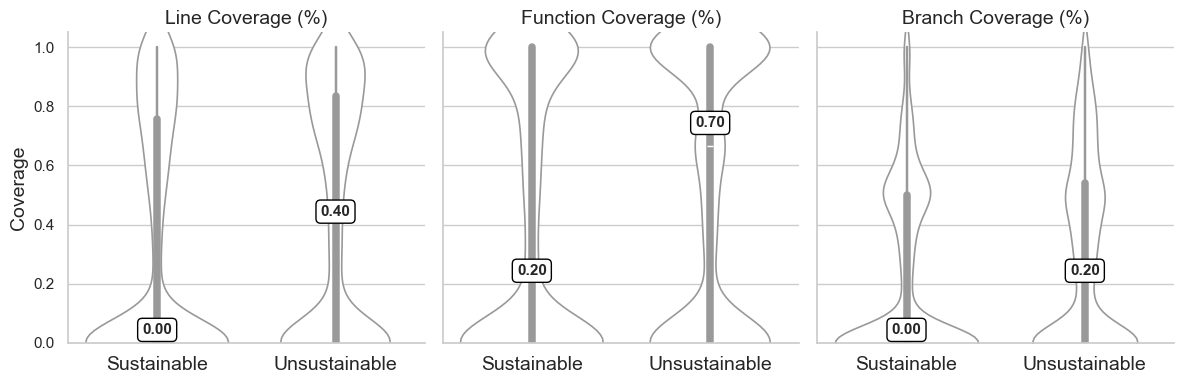

In [1242]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define the 3 metrics
metrics = [
    ("line_percent", "Line Coverage (%)"),
    ("function_percent", "Function Coverage (%)"),
    ("branch_percent", "Branch Coverage (%)")
]

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (metric, label) in zip(axes, metrics):
    # Prepare combined data
    df = pd.DataFrame({
        "Coverage": pd.concat([
            sustainable_df[metric],
            unsustainable_df[metric]
        ], ignore_index=True),
        "Status": ["Sustainable"] * len(sustainable_df) + ["Unsustainable"] * len(unsustainable_df)
    })

    # Draw violin + box
    sns.violinplot(x="Status", y="Coverage", data=df,
                   inner="box", ax=ax, color="white", linewidth=1.2)

    # Annotate medians
    for i, group in enumerate(["Sustainable", "Unsustainable"]):
        median_val = round(df[df["Status"] == group]["Coverage"].median(), 1)
        ax.text(i, median_val + 0.02, f"{median_val:.2f}",
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    ax.set_title(label, fontsize=14)  # ⬅️ Increased title font size
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)


    # Set x-tick labels (bottom) with consistent size and alignment
    ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)
    
    if ax == axes[0]:
        ax.set_ylabel("Coverage",fontsize=14)
    else:
        ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/j3/ksjvw7w15pxb38r8w1yqctl00000gr/T/ipykernel_52938/1525008549.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)


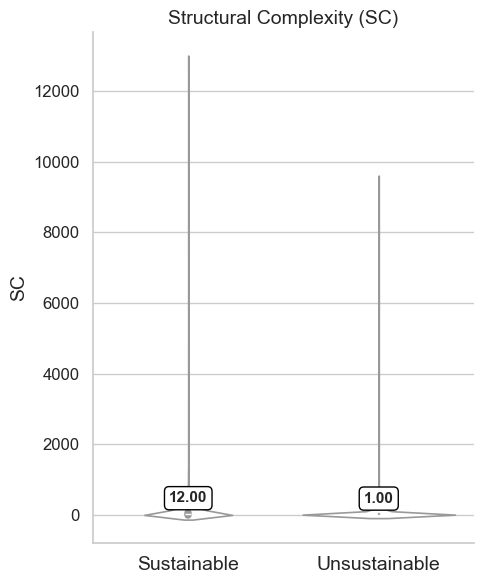

In [1243]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define the single metric
metric = "SC"
label = "Structural Complexity (SC)"

# Create the figure
fig, ax = plt.subplots(figsize=(5, 6))  # Adjust size as needed

# Combine data from both groups
df = pd.DataFrame({
    "SC": pd.concat([
        sustainable_df[metric],
        unsustainable_df[metric]
    ], ignore_index=True),
    "Status": ["Sustainable"] * len(sustainable_df) + ["Unsustainable"] * len(unsustainable_df)
})

# Draw violin + box plot
sns.violinplot(x="Status", y="SC", data=df,
               inner="box", ax=ax, color="white", linewidth=1.2)

# Annotate medians
for i, group in enumerate(["Sustainable", "Unsustainable"]):
    median_val = round(df[df["Status"] == group]["SC"].median(), 1)
    ax.text(i, median_val + 0.02 * df["SC"].max(), f"{median_val:.2f}",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

# Title and labels
ax.set_title(label, fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("SC", fontsize=14)
ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)
ax.tick_params(axis='y', labelsize=12)

sns.despine()
plt.tight_layout()
plt.show()


/var/folders/j3/ksjvw7w15pxb38r8w1yqctl00000gr/T/ipykernel_52938/3093271796.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)


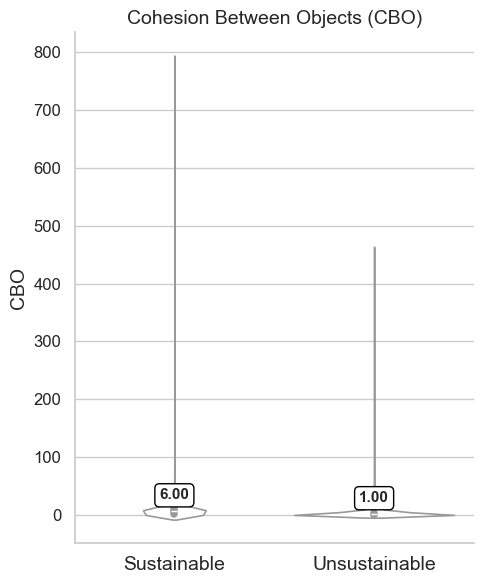

In [1244]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define the single metric
metric = "CBO"
label = "Cohesion Between Objects (CBO)"

# Create the figure
fig, ax = plt.subplots(figsize=(5, 6))  # Adjust size as needed

# Combine data from both groups
df = pd.DataFrame({
    "CBO": pd.concat([
        sustainable_df[metric],
        unsustainable_df[metric]
    ], ignore_index=True),
    "Status": ["Sustainable"] * len(sustainable_df) + ["Unsustainable"] * len(unsustainable_df)
})

# Draw violin + box plot
sns.violinplot(x="Status", y="CBO", data=df,
               inner="box", ax=ax, color="white", linewidth=1.2)

# Annotate medians
for i, group in enumerate(["Sustainable", "Unsustainable"]):
    median_val = round(df[df["Status"] == group]["CBO"].median(), 1)
    ax.text(i, median_val + 0.02 * df["CBO"].max(), f"{median_val:.2f}",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

# Title and labels
ax.set_title(label, fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("CBO", fontsize=14)
ax.set_xticklabels(["Sustainable", "Unsustainable"], fontsize=14)
ax.tick_params(axis='y', labelsize=12)

sns.despine()
plt.tight_layout()
plt.show()


# Overall Correlation

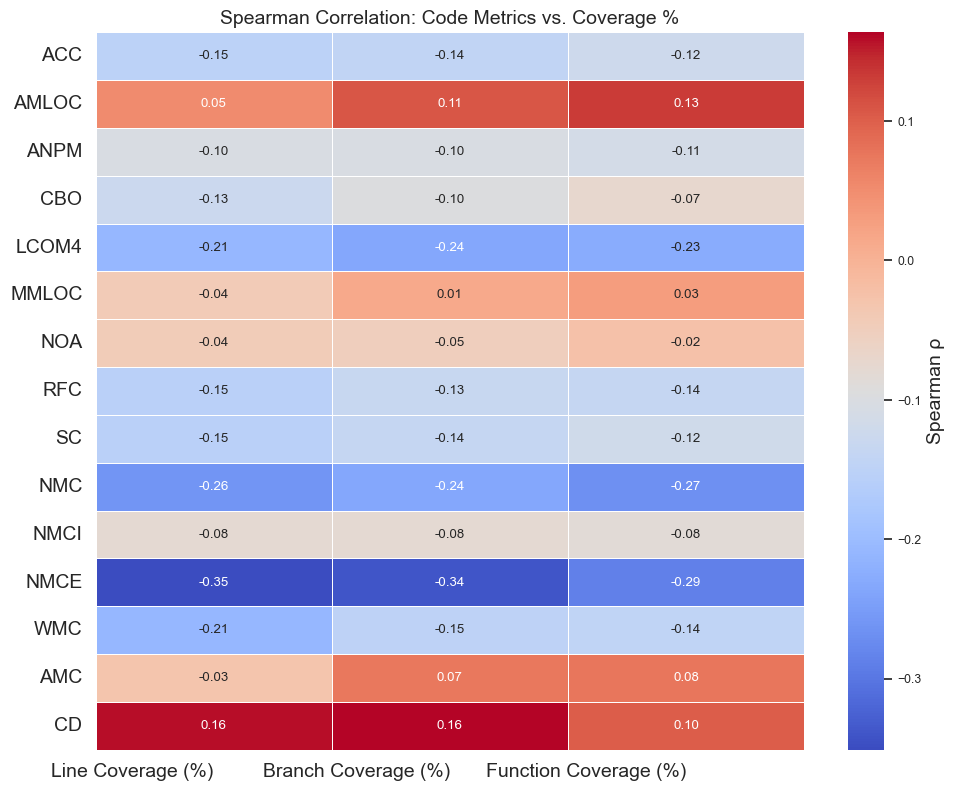

In [1577]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define metric groups
coverage_metrics = ['line_percent', 'branch_percent', 'function_percent']
code_metrics = [
    'ACC', 'AMLOC', 'ANPM', 'CBO', 'LCOM4', 'MMLOC', 'NOA',
    'RFC', 'SC', 'NMC', 'NMCI', 'NMCE', 'WMC', 'AMC', 'Comment_Density'
]

# Combine and clean
combined_df = pd.concat([sustainable_df, unsustainable_df], ignore_index=True)
df_filtered = combined_df[code_metrics + coverage_metrics].dropna().apply(pd.to_numeric, errors='coerce')

# Compute Spearman correlation matrix
corr_matrix = df_filtered.corr(method='spearman')

# Slice: code metrics as rows, coverage metrics as columns
partial_corr = corr_matrix.loc[code_metrics, coverage_metrics]

# Rename selected labels
partial_corr = partial_corr.rename(
    columns={
        'line_percent': 'Line Coverage (%)',
        'branch_percent': 'Branch Coverage (%)',
        'function_percent': 'Function Coverage (%)'
    },
    index={
        'Comment_Density': 'CD'
    }
)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    partial_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

# Increase colorbar label font size
colorbar = ax.collections[0].colorbar
colorbar.set_label("Spearman ρ", fontsize=14)

# Increase axis tick label font sizes
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, rotation=0, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, rotation=0)

# Title and layout
plt.title("Spearman Correlation: Code Metrics vs. Coverage %", fontsize=14)
plt.tight_layout()
plt.savefig("overall_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()



# Overall Coverage

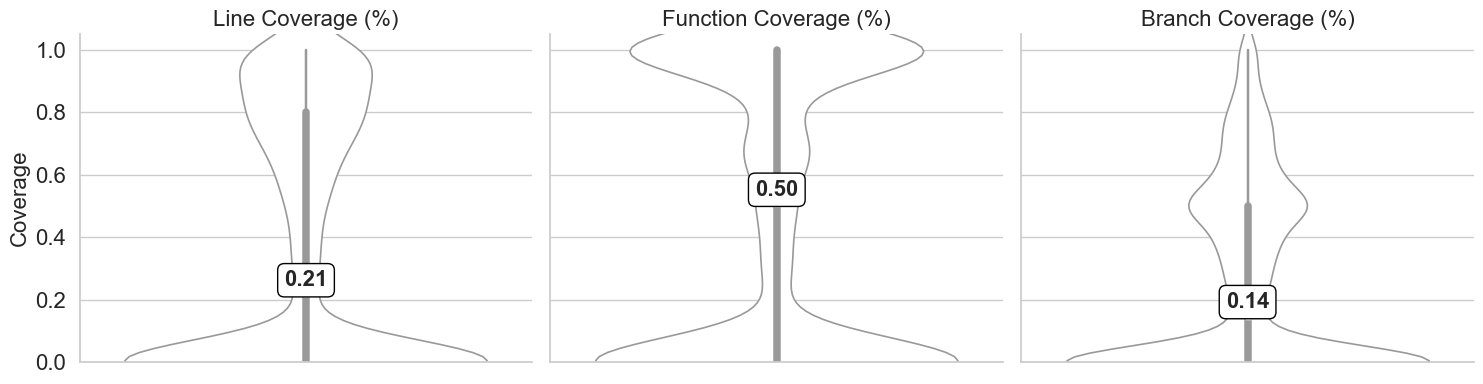

In [1578]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define the 3 metrics and their labels
metrics = [
    ("line_percent", "Line Coverage (%)"),
    ("function_percent", "Function Coverage (%)"),
    ("branch_percent", "Branch Coverage (%)")
]

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (metric, label) in zip(axes, metrics):
    # Combine sustainable + unsustainable data
    combined_data = pd.DataFrame({
        "Coverage": pd.concat([
            sustainable_df[metric],
            unsustainable_df[metric]
        ], ignore_index=True)
    })

    # Plot a vertical violin+box for the combined data
    sns.violinplot(y="Coverage", data=combined_data, inner="box",
                   ax=ax, color="white", linewidth=1.2)

    # Annotate median with rounded box
    median_val = round(combined_data["Coverage"].median(), 2)
    ax.text(0, median_val + 0.02, f"{median_val:.2f}",
            ha='center', va='bottom',
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    # Format each subplot
    ax.set_title(label, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Coverage", fontsize=16)
    ax.set_xticks([])  # Hide x-axis ticks (only one value)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0, 1.05)

sns.despine()
plt.tight_layout()
plt.savefig("overall_coverage.png", dpi=300, bbox_inches='tight')
plt.show()


# Normality test

In [1579]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest

# Example DataFrame
np.random.seed(42)
df = df_filtered 

# Apply the test to each column
results = {}

for col in df.columns:
    stat, p = normaltest(df[col].dropna())  # Drop NaNs if present
    results[col] = {
        'K2_Statistic': stat,
        'P_Value': p,
        'Normal': p > 0.05  # True if not significantly different from normal
    }

# Convert to DataFrame for easier viewing
results_df = pd.DataFrame(results).T
print(results_df)

                  K2_Statistic P_Value Normal
ACC                12410.79643     0.0  False
AMLOC             10726.972981     0.0  False
ANPM               2218.764986     0.0  False
CBO               15029.385641     0.0  False
LCOM4             10352.624882     0.0  False
MMLOC              12477.55366     0.0  False
NOA               11962.362164     0.0  False
RFC               10111.076342     0.0  False
SC                14782.964146     0.0  False
NMC                2748.457662     0.0  False
NMCI              23757.253705     0.0  False
NMCE               3467.880195     0.0  False
WMC               10330.294211     0.0  False
AMC                9397.133945     0.0  False
Comment_Density    9335.918906     0.0  False
line_percent      28349.673224     0.0  False
branch_percent     1511.800502     0.0  False
function_percent  25115.450416     0.0  False
